# Reproduce & explore — adaptive quantum metrology under resource constraints

One notebook to (1) demonstrate the estimator, (2) show the reproduced results tables, (3) view the
figures, and (4) let you tweak the parameter grids yourself. All numbers are the **fixed-budget**,
de-biased results (tune seed 42, validate seed 2024, R = 40,000); the heavy computation lives in
`analysis/extensive_sweep.py`, this notebook reads its outputs and lets you experiment cheaply.

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
from qmetrology import experiments as E
from qmetrology.algorithms import (
    find_phi_fixed_budget_brute_force as BRUTE,
    find_phi_fixed_budget_linear_search as LINEAR,
    find_phi_fixed_budget_binary_search as BINARY,
    find_phi_fixed_budget_reverse_engineering as REVERSE,
)
pd.set_option("display.max_columns", None)
print("ready")

ready


## 1. The model and the estimator

The entangled circuit reads out `0` with true probability `p0 = cos^2(N*phi)`. Drawing `m` shots gives
`k ~ Binomial(m, p0)`; the estimate is `phat0 = k/m` and `phi_hat = arccos(sqrt(phat0)) / N`.

The function below is exactly *Algorithm: SimulateEntangledProtocol* — for each shot count `m` it repeats
the measurement `R` times and records the mean absolute error and the sample variance of the estimates.

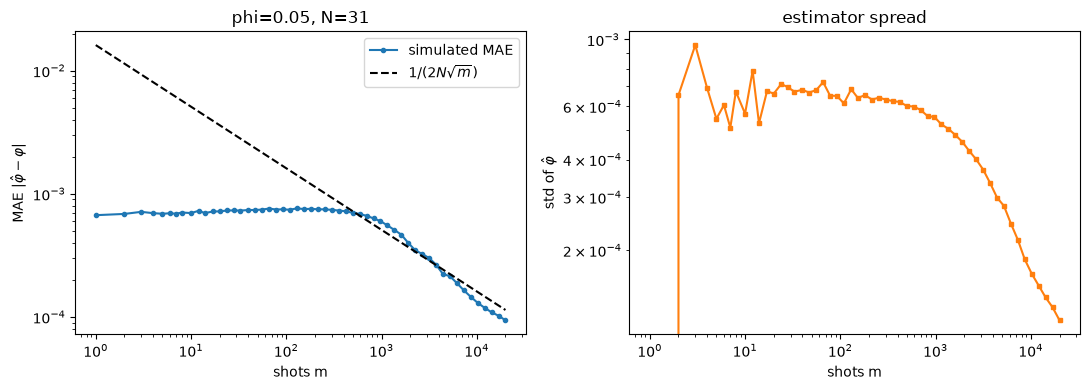

In [2]:
def simulate_entangled_protocol(phi, R, m_values, N, rng):
    p0 = np.cos(N * phi) ** 2                       # true P('0') for the entangled circuit
    mae, var = [], []
    for m in m_values:
        k = rng.binomial(m, p0, size=R)            # number of '0' outcomes in m shots
        phi_hat = np.arccos(np.sqrt(k / m)) / N    # estimate per repetition
        mae.append(np.mean(np.abs(phi_hat - phi)))
        var.append(np.var(phi_hat, ddof=1))
    return np.array(mae), np.array(var)

phi, N = 0.05, 31                                   # N = N_min for phi_max = 0.05
m_values = np.unique(np.geomspace(1, 20000, 60).astype(int))
mae, var = simulate_entangled_protocol(phi, R=3000, m_values=m_values, N=N, rng=np.random.default_rng(0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(m_values, mae, "o-", ms=3, label="simulated MAE")
ax[0].loglog(m_values, 1 / (2 * N * np.sqrt(m_values)), "k--", label=r"$1/(2N\sqrt{m})$")
ax[0].set(xlabel="shots m", ylabel=r"MAE $|\hat\phi-\phi|$", title=f"phi={phi}, N={N}"); ax[0].legend()
ax[1].loglog(m_values, np.sqrt(var), "s-", ms=3, color="C1")
ax[1].set(xlabel="shots m", ylabel=r"std of $\hat\phi$", title="estimator spread")
plt.tight_layout(); plt.show()

## 2. The results tables (fixed-budget, de-biased)

Loaded from `results/all_numbers.csv` and `results/story_cube.csv` (regenerate with
`python analysis/extensive_sweep.py && python -m qmetrology.reproduce`).

In [3]:
nums = pd.read_csv("results/all_numbers.csv")
cube = pd.read_csv("results/story_cube.csv")
nice = {"separable":"Separable (N=1)","brute":"Brute force","linear":"Linear search",
        "binary":"Binary search","reverse_eng":"Reverse engineering"}

# --- Table 3.1: % converged at fixed budget 10,000 (narrow) ---
t31 = (nums[nums.table=="3.1"].assign(Algorithm=lambda d: d.algorithm.map(nice))
       [["Algorithm","value"]].rename(columns={"value":"% converged @10k"}))
print("Table 3.1  (eps=1e-3, U(0.01,0.1))"); display(t31.reset_index(drop=True))

Table 3.1  (eps=1e-3, U(0.01,0.1))


,Algorithm,% converged @10k


In [4]:
# --- Table 3.2: budget to reach 90% convergence, ratio vs brute ---
cols = [("eps 1e-3 U(0.01,0.1)","U(0.01,0.1), eps=1e-03"),
        ("eps 1e-4 U(0.01,0.1)","U(0.01,0.1), eps=1e-04"),
        ("eps 1e-4 U(0.001,0.01)","U(0.001,0.01), eps=1e-04"),
        ("eps 1e-4 U(0.001,0.1)","U(0.001,0.1), eps=1e-04")]
rows = []
for algo in ["brute","linear","binary","reverse_eng"]:
    row = {"Algorithm": nice[algo]}
    for label, setting in cols:
        r = cube[(cube.setting==setting)&(cube.algo==algo)&(cube.threshold_pct==90)]
        if len(r) and pd.notna(r.budget_to_reach.iloc[0]):
            b, ratio = r.budget_to_reach.iloc[0], r.ratio_vs_brute.iloc[0]
            row[label] = f"{b:,.0f}" + ("" if algo=="brute" else f"  (x{ratio:.2f})")
        else:
            row[label] = "-"
    rows.append(row)
print("Table 3.2  (budget to reach 90%; ratio = brute / algorithm)")
display(pd.DataFrame(rows))

Table 3.2  (budget to reach 90%; ratio = brute / algorithm)


,Algorithm,"eps 1e-3 U(0.01,0.1)","eps 1e-4 U(0.01,0.1)","eps 1e-4 U(0.001,0.01)","eps 1e-4 U(0.001,0.1)"
0,Brute force,"45,868","4,504,343","440,367","4,516,936"
1,Linear search,"43,218 (x1.06)","3,135,633 (x1.44)","416,087 (x1.06)","3,451,483 (x1.31)"
2,Binary search,"58,396 (x0.79)","3,436,485 (x1.31)","800,957 (x0.55)","4,941,085 (x0.91)"
3,Reverse engineering,"37,197 (x1.23)","2,890,389 (x1.56)","362,887 (x1.21)","2,911,267 (x1.55)"


In [5]:
# --- Table 3.3: broad distributions, % converged at budget 10k ---
t33 = (nums[nums.table=="3.3"].assign(Algorithm=lambda d: d.algorithm.map(nice))
       .pivot_table(index="Algorithm", columns="setting", values="value")
       [["pi/2","pi/4","pi/8","pi/16"]] if (nums.table=="3.3").any() else pd.DataFrame())
print("Table 3.3  (% converged @10k, broad distributions)"); display(t33)

Table 3.3  (% converged @10k, broad distributions)


""


## 3. The figures

`fig_story` (convergence vs budget with the budget-ratio arrow), `fig_error` (estimator error +
uncertainty, down to eps=1e-8), `fig_pareto` (budget-convergence frontier + dominance), and
`fig_precision` (advantage vs precision).

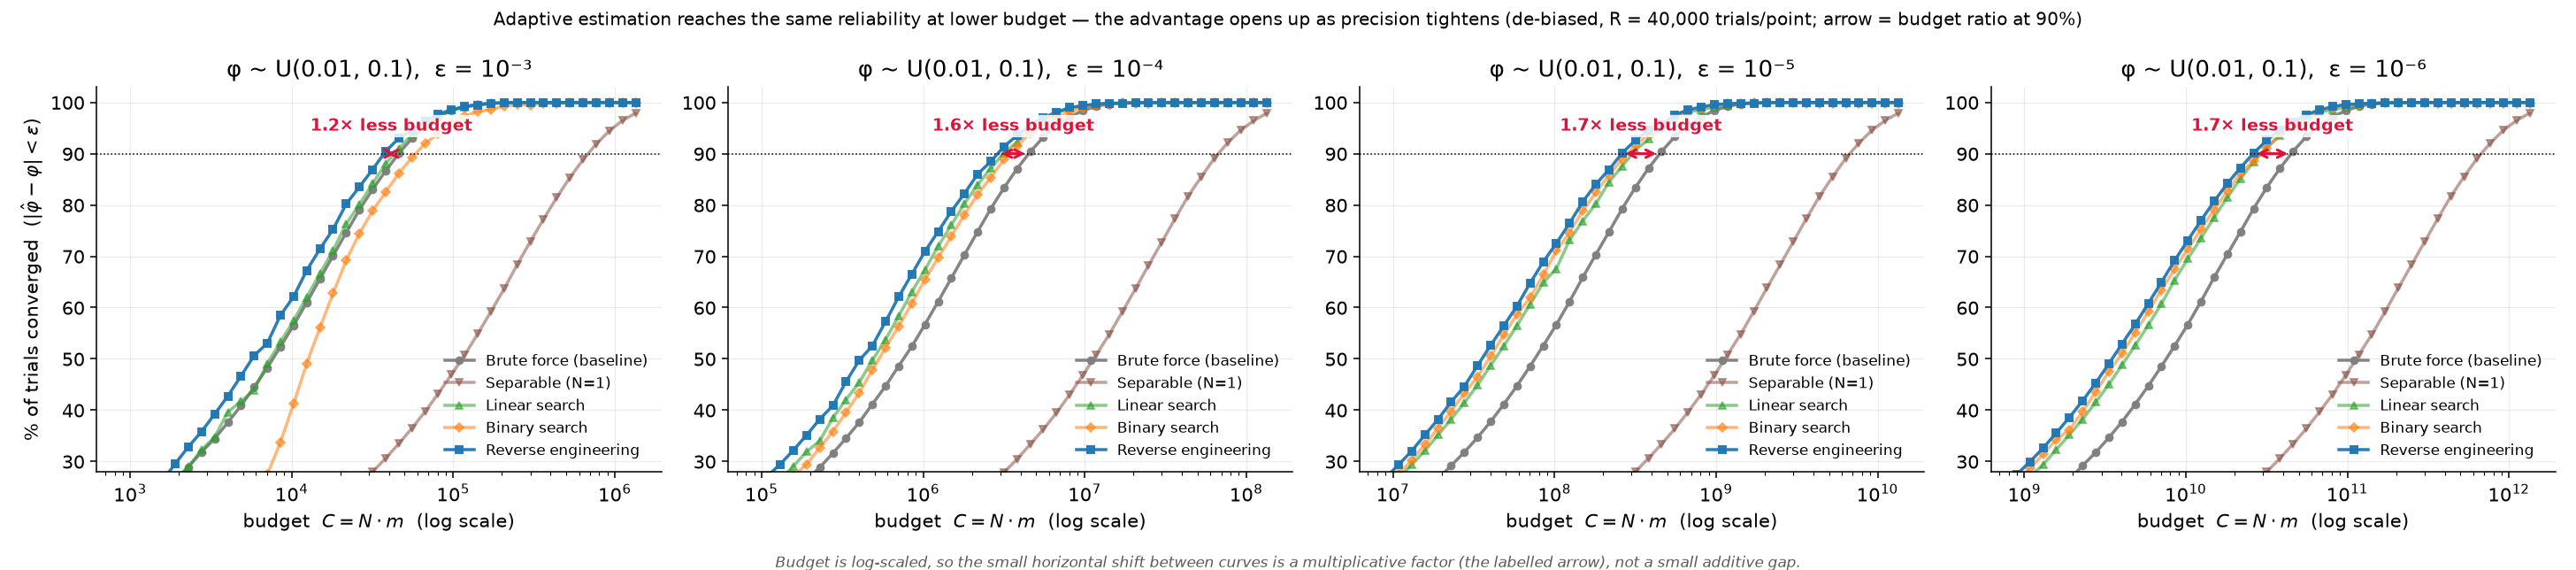

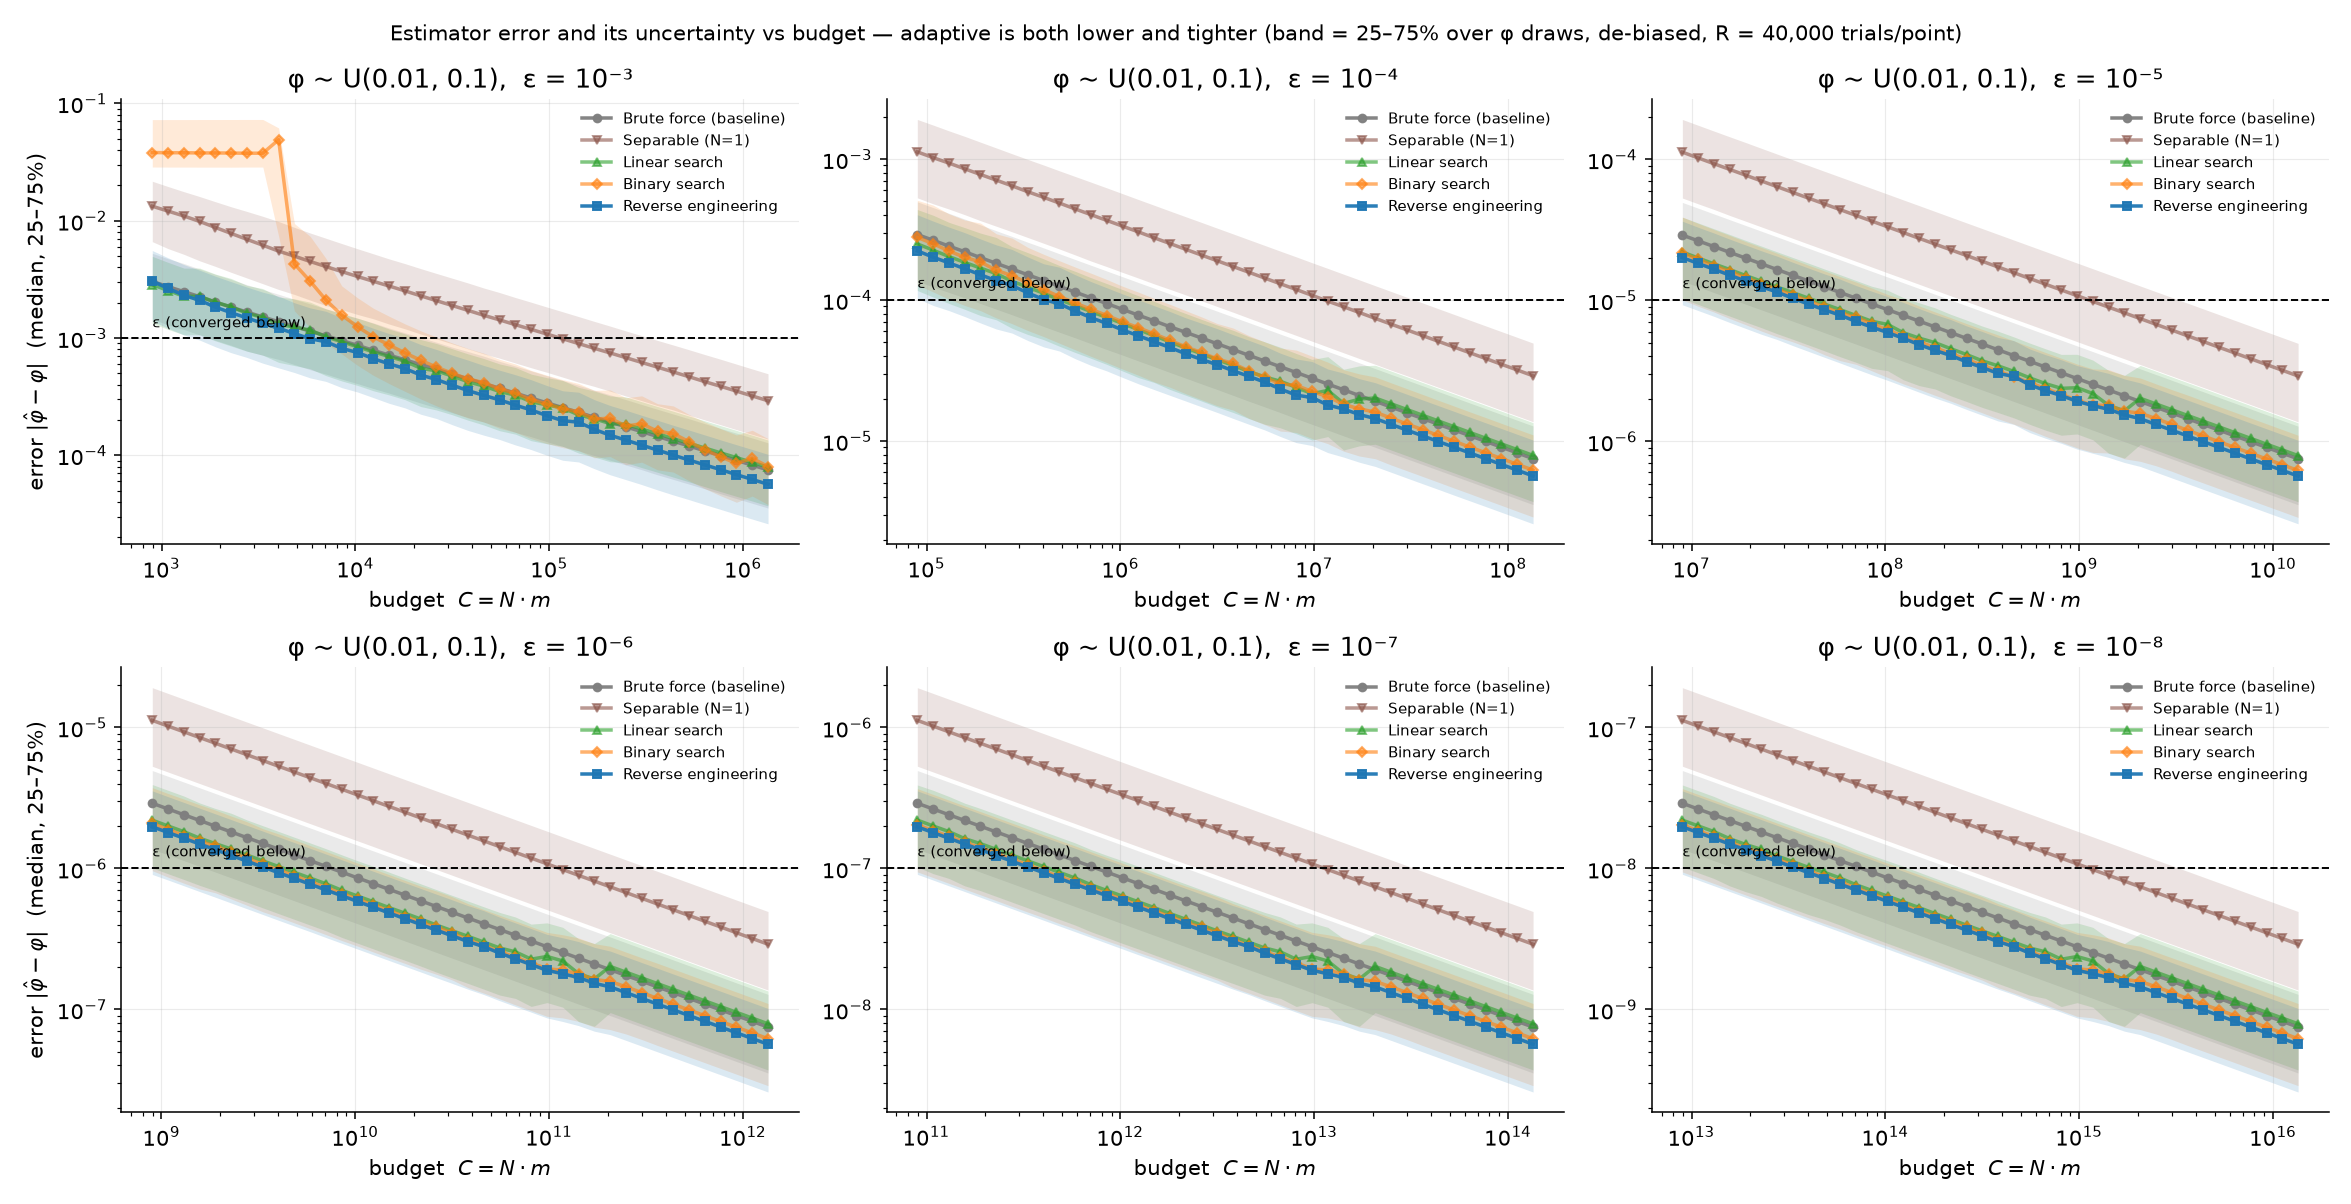

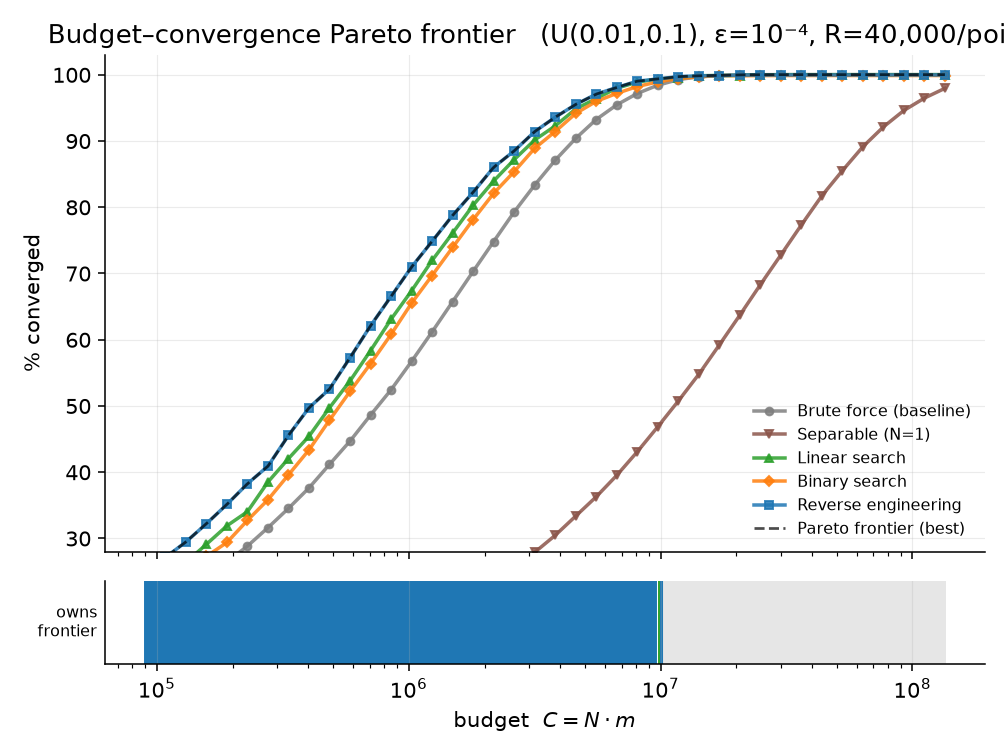

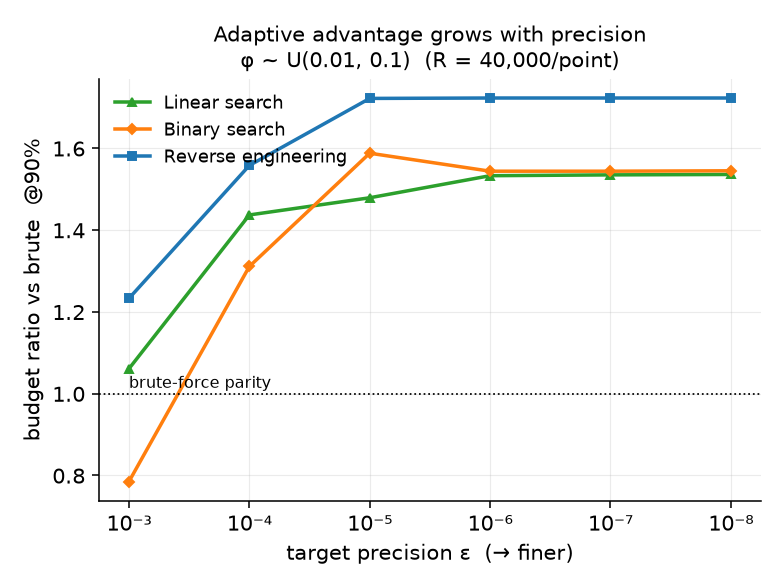

In [6]:
from IPython.display import Image, display
for f in ["fig_story.png","fig_error.png","fig_pareto.png","fig_precision.png"]:
    display(Image(filename=f"results/{f}"))

## 4. Play — tweak the parameter grid

Change `SETTING`, `BUDGET`, and the grid below and re-run. `experiments.grid_full` returns
`(success_rate, mean_budget, params)` for every combination (tuned on seed 42); sort/filter to taste.
Swap `REVERSE` for `LINEAR` / `BINARY` / `BRUTE` to explore other algorithms.

In [7]:
SETTING = dict(phi_min=0.01, phi_max=0.1, eps=1e-4)   # <- tweak
BUDGET  = 2_000_000                                    # <- tweak
FN = REVERSE                                           # <- tweak: LINEAR / BINARY / REVERSE

grid = {                                               # <- tweak the search grid
    "m_exploration": np.unique(np.geomspace(20, 5000, 14).astype(int)),
    "safeguard": [0.8, 0.85, 0.9, 0.95],
    "budget": [BUDGET],
}
res = E.grid_full(FN, grid, R=1500, seed=42, **SETTING)
df = (pd.DataFrame([{**c, "rate": r, "mean_budget": b} for r, b, c in res])
        .sort_values("rate", ascending=False).drop(columns=["budget"]).head(10).reset_index(drop=True))
print(f"top configs for {FN.__name__} at budget {BUDGET:,} (rate = fraction converged, R=1500 tune seed)")
display(df)

# de-bias the winner: re-check the top config on the independent seed 2024
best = max(res, key=lambda x: x[0])[2]
val = E.success_rate(FN, best, R=20000, seed=2024, **SETTING)
print(f"best config {best}\n  tuned rate vs de-biased (seed 2024, R=20k): {max(r for r,_,_ in res):.3f} -> {val:.3f}")

top configs for find_phi_fixed_budget_reverse_engineering at budget 2,000,000 (rate = fraction converged, R=1500 tune seed)


,m_exploration,safeguard,rate,mean_budget
0,3269,0.95,0.856000,1.999983e+06
1,5000,0.95,0.854667,1.999985e+06
2,2138,0.95,0.854000,1.999982e+06
3,2138,0.90,0.850000,1.999983e+06
4,3269,0.90,0.846667,1.999982e+06
5,1398,0.90,0.843333,1.999983e+06
6,5000,0.90,0.842667,1.999986e+06
7,2138,0.85,0.840000,1.999983e+06
8,597,0.85,0.839333,1.999986e+06
9,1398,0.95,0.839333,1.999980e+06


best config {'m_exploration': np.int64(3269), 'safeguard': 0.95, 'budget': 2000000}
  tuned rate vs de-biased (seed 2024, R=20k): 0.856 -> 0.843


## Regenerate everything

```bash
python analysis/extensive_sweep.py   # budget sweep (--fine ~1h, --max ~4.5h)  -> story_*.csv
python analysis/error_curves.py      # estimator-error curves                  -> error_curves.csv
python analysis/render_story.py      # the four figures
python -m qmetrology.reproduce       # assemble results/RESULTS.md
```
Archived variable-budget algorithms and the old notebooks live in `legacy/`.